# Intra-study spatial autocorrelation (core network posonly distances)

For each individual NAFLD study, restrict the *core* correlation network's
`posonly` graph distances (positive-edges-only, dijkstra distance = 1 - r) to
that study's own tested metabolites, and use that study's own raw Kendall tau
(not the cross-study weighted average) as the attribute. Same method as the
main NAFLD spatial-autocorrelation notebook (inverse-distance row-standardized
weights, global Moran's I + LISA, both permutation-tested), just run
per-study instead of pooled -- this is the "same-study" baseline half of the
same-study vs. cross-study comparison: does tau look spatially autocorrelated
*within* a single study's own cohort on its own, before asking whether that
signal also holds *across* studies.

Note: distances are still taken from the full core graph (paths may route
through metabolites outside this study), only the node set (rows/columns) is
restricted to this study's metabolites.

In [37]:
import glob
import sys

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib import pyplot as plt

from utils.path import find_root

ROOT = find_root()
sys.path.insert(0, str(ROOT / "src"))

from mwnetwork import config
from mwnetwork.kegg_enrichment import kegg_wilcoxon, exclude_disease_pathways

CORE_GRAPH_DIR = ROOT / "checkpoints" / "metabolomics_workbench" / "core_graph"
NAFLD_ANALYSIS_DIR = ROOT / "checkpoints" / "metabolomics_workbench" / "nafld_analysis"

N_PERM = 9999
rng = np.random.default_rng(0)


In [38]:
D_full = pd.read_csv(CORE_GRAPH_DIR / "graph_distances_posonly.csv", index_col=0)
print("core graph (posonly) nodes:", D_full.shape[0])

study_files = sorted(glob.glob(str(NAFLD_ANALYSIS_DIR / "*.csv")))
print(len(study_files), "study file(s):", [f.split("/")[-1] for f in study_files])


core graph (posonly) nodes: 4429
9 study file(s): ['ST000916_nafld_severity.csv', 'ST000977_nafld_vs_healthy.csv', 'ST001710_nafld_severity.csv', 'ST001711_nafld_severity.csv', 'ST001842_nafld_vs_healthy.csv', 'ST001843_nafld_vs_healthy.csv', 'ST001964_nafld_severity.csv', 'ST002091_nafld_vs_healthy.csv', 'ST002269_nafld_vs_healthy.csv']


## Moran's I / LISA machinery (same as the main notebook)

In [58]:
# def build_inverse_distance_weights(D):
#     Dv = D.values.astype(float)
#     np.fill_diagonal(Dv, np.inf)
#     W = 1.0 / Dv
#     return W / W.sum(axis=1, keepdims=True)

def build_inverse_distance_weights(D):
    assert np.all(D>=0), "Distance matrix must be non-negative"
    Dv = D.values.astype(float)
    np.fill_diagonal(Dv, 0)
    W = (1 - Dv)**2
    return W / W.sum(axis=1, keepdims=True)


def global_moran(z, W_std):
    n = len(z)
    S0 = W_std.sum()
    num = z @ (W_std @ z)
    den = z @ z
    return (n / S0) * (num / den)


def global_moran_test(x, W_std, n_perm=N_PERM, rng=None):
    rng = rng or np.random.default_rng()
    z = x - x.mean()
    I_obs = global_moran(z, W_std)

    perm_I = np.empty(n_perm)
    for k in range(n_perm):
        xp = rng.permutation(x)
        zp = xp - xp.mean()
        perm_I[k] = global_moran(zp, W_std)

    mean_perm, sd_perm = perm_I.mean(), perm_I.std(ddof=1)
    z_score = (I_obs - mean_perm) / sd_perm
    p_value = (np.sum(np.abs(perm_I - mean_perm) >= np.abs(I_obs - mean_perm)) + 1) / (n_perm + 1)
    return I_obs, z_score, p_value, perm_I


def local_moran(z, W_std):
    m2 = (z ** 2).mean()
    lag = W_std @ z
    return (z / m2) * lag


def local_moran_test(x, W_std, n_perm=N_PERM, rng=None):
    # See main notebook: a single full permutation per replicate can be reused
    # for every node's lag since W_std has a zero diagonal (w_ii=0 zeroes out
    # whatever lands on position i), so this is a conditional permutation
    # without an O(n_perm * n) python loop.
    rng = rng or np.random.default_rng()
    z = x - x.mean()
    m2 = (z ** 2).mean()
    I_local = local_moran(z, W_std)

    perm_I = np.empty((n_perm, len(x)))
    for k in range(n_perm):
        zp = rng.permutation(z)
        lag_perm = W_std @ zp
        perm_I[k] = (z / m2) * lag_perm

    mean_perm = perm_I.mean(axis=0)
    sd_perm = perm_I.std(axis=0, ddof=1)
    z_scores = (I_local - mean_perm) / sd_perm
    p_values = (np.sum(np.abs(perm_I - mean_perm) >= np.abs(I_local - mean_perm), axis=0) + 1) / (n_perm + 1)
    return I_local, z_scores, p_values


def run_lisa(x, W_std, nodes, n_perm=N_PERM, rng=None):
    z = x - x.mean()
    I_local, local_z, local_p = local_moran_test(x, W_std, n_perm=n_perm, rng=rng)

    lag = W_std @ z
    quadrant = np.where(
        (z >= 0) & (lag >= 0), "HH",
        np.where((z < 0) & (lag < 0), "LL",
        np.where((z >= 0) & (lag < 0), "HL", "LH")),
    )
    q_values = multipletests(local_p, method="fdr_bh")[1]

    lisa = pd.DataFrame({
        "tau": x, "local_I": I_local, "z_score": local_z,
        "p_value": local_p, "q_value": q_values, "quadrant": quadrant,
    }, index=nodes)
    lisa["significant"] = lisa["q_value"] < 0.05
    return lisa


## Per-study global Moran's I + LISA

In [59]:
results = []
lisa_by_study = {}

for f in study_files:
    study_id = f.split("/")[-1].split("_", 1)[0]

    df = pd.read_csv(f).dropna(subset=["kendall_tau"])
    df = df.groupby("refmet_id")["kendall_tau"].mean()  # in case of duplicate rows per metabolite

    nodes = D_full.index.intersection(df.index)
    D = D_full.loc[nodes, nodes]
    x = df.loc[nodes].values.astype(float)
    n = len(nodes)

    W_std = build_inverse_distance_weights(D)
    z = x - x.mean()

    I_obs, z_score, p_value, _ = global_moran_test(x, W_std, n_perm=N_PERM, rng=rng)
    lisa = run_lisa(x, W_std, nodes, n_perm=N_PERM, rng=rng)
    lisa_by_study[study_id] = lisa

    n_pos_sig = (lisa["significant"] & (lisa["local_I"] > 0)).sum()
    n_neg_sig = (lisa["significant"] & (lisa["local_I"] < 0)).sum()

    results.append({
        "study_id": study_id,
        "n_nodes": n,
        "global_I": I_obs,
        "z_score": z_score,
        "p_value": p_value,
        "n_lisa_significant": int(lisa["significant"].sum()),
        "n_lisa_pos_significant": int(n_pos_sig),
        "n_lisa_neg_significant": int(n_neg_sig),
        "lisa_pos_ratio": n_pos_sig / n,
        "lisa_neg_ratio": n_neg_sig / n,
    })

    print(f"{study_id}: n={n:4d}  I={I_obs:+.4f}  z={z_score:+.2f}  p={p_value:.4g}  "
          f"LISA sig={lisa['significant'].sum()}/{n} (pos={n_pos_sig}, neg={n_neg_sig})")

summary = pd.DataFrame(results).set_index("study_id")
summary


ST000916: n= 257  I=+0.1010  z=+12.09  p=0.0001  LISA sig=112/257 (pos=98, neg=14)
ST000977: n=  61  I=+0.1643  z=+3.07  p=0.006  LISA sig=4/61 (pos=4, neg=0)
ST001710: n= 135  I=+0.2385  z=+39.42  p=0.0001  LISA sig=112/135 (pos=99, neg=13)
ST001711: n=  31  I=+0.0481  z=-0.31  p=0.7389  LISA sig=0/31 (pos=0, neg=0)
ST001842: n= 140  I=+0.1387  z=+9.55  p=0.0001  LISA sig=25/140 (pos=25, neg=0)
ST001843: n= 268  I=+0.2231  z=+65.95  p=0.0001  LISA sig=207/268 (pos=189, neg=18)
ST001964: n=  15  I=+0.3644  z=+2.87  p=0.0051  LISA sig=9/15 (pos=9, neg=0)
ST002091: n= 679  I=+0.1101  z=+41.38  p=0.0001  LISA sig=606/679 (pos=433, neg=173)
ST002269: n= 309  I=+0.0780  z=+12.66  p=0.0001  LISA sig=105/309 (pos=93, neg=12)


,n_nodes,global_I,z_score,p_value,n_lisa_significant,n_lisa_pos_significant,n_lisa_neg_significant,lisa_pos_ratio,lisa_neg_ratio
study_id,,,,,,,,,
ST000916,257,0.100999,12.088787,0.0001,112,98,14,0.381323,0.054475
ST000977,61,0.164273,3.066307,0.0060,4,4,0,0.065574,0.000000
ST001710,135,0.238478,39.417227,0.0001,112,99,13,0.733333,0.096296
ST001711,31,0.048136,-0.312011,0.7389,0,0,0,0.000000,0.000000
ST001842,140,0.138671,9.553885,0.0001,25,25,0,0.178571,0.000000
ST001843,268,0.223051,65.948581,0.0001,207,189,18,0.705224,0.067164
ST001964,15,0.364400,2.872511,0.0051,9,9,0,0.600000,0.000000
ST002091,679,0.110147,41.379344,0.0001,606,433,173,0.637703,0.254786
ST002269,309,0.078037,12.657963,0.0001,105,93,12,0.300971,0.038835


## Global Moran's I per study

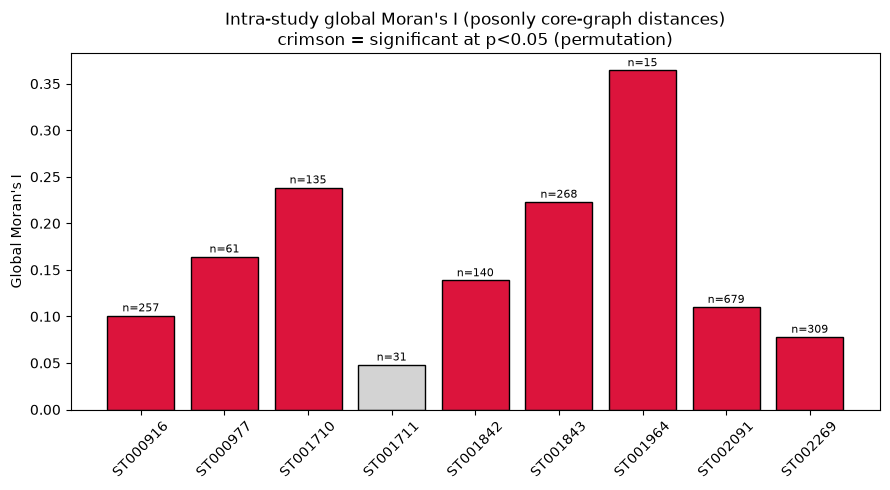

In [60]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["crimson" if p < 0.05 else "lightgrey" for p in summary["p_value"]]
bars = ax.bar(summary.index, summary["global_I"], color=colors, edgecolor="black")
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("Global Moran's I")
ax.set_title("Intra-study global Moran's I (posonly core-graph distances)\ncrimson = significant at p<0.05 (permutation)")
ax.tick_params(axis="x", rotation=45)
for bar, n in zip(bars, summary["n_nodes"]):
    ax.annotate(f"n={n}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                textcoords="offset points", xytext=(0, 3 if bar.get_height() >= 0 else -12),
                ha="center", fontsize=8)
fig.tight_layout()
plt.show()


## LISA significance ratio per study (positive vs. negative autocorrelation)

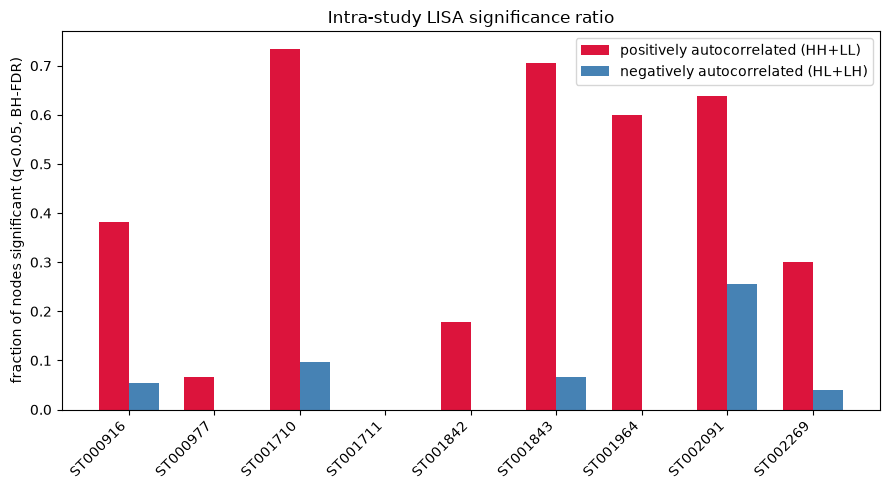

In [61]:
fig, ax = plt.subplots(figsize=(9, 5))
width = 0.35
xpos = np.arange(len(summary))
ax.bar(xpos - width / 2, summary["lisa_pos_ratio"], width, color="crimson", label="positively autocorrelated (HH+LL)")
ax.bar(xpos + width / 2, summary["lisa_neg_ratio"], width, color="steelblue", label="negatively autocorrelated (HL+LH)")
ax.set_xticks(xpos)
ax.set_xticklabels(summary.index, rotation=45, ha="right")
ax.set_ylabel("fraction of nodes significant (q<0.05, BH-FDR)")
ax.set_title("Intra-study LISA significance ratio")
ax.legend()
fig.tight_layout()
plt.show()


# Per-study KEGG pathway enrichment (Wilcoxon rank-sum on tau)

No network involved here, metabolite-per-metabolite: for each study, map its
tested metabolites' raw Kendall tau (treated as the logFC-analogue) to KEGG
compound IDs, then run `kegg_wilcoxon` (new function in
`mwnetwork.kegg_enrichment`) per pathway -- a competitive Mann-Whitney U test
of the pathway's member tau values against every other measured metabolite in
that study. That study's own measured/mapped metabolites are the background,
so no significance cutoff on individual metabolites is needed first (unlike
`kegg_ora`), and small KEGG compound sets get a more stable null than
`kegg_gsea`'s permutation-based running-sum.

Only *strict* KEGG "Human Disease" pathways are excluded via
`exclude_disease_pathways`: every map-05xxx entry (cancer, infection,
neurodegenerative/cardiovascular/autoimmune disease, ...) plus the handful of
disease pathways KEGG instead files under 04930-04934/04940 (diabetes,
insulin resistance, Cushing syndrome and -- the one that actually matters
here -- hsa04932 "Non-alcoholic fatty liver disease" itself, which would
trivially "enrich" in a NAFLD case-control study). Everything else survives,
including physiology pathways that just happen to sit outside KEGG's narrow
Metabolism category (e.g. hsa04976 Bile secretion, hsa04979 Cholesterol
metabolism).

In [62]:
import sspa

refmet_to_kegg = pd.read_csv(config.REFMET_CSV_PATH, index_col="refmet_id")["kegg_id"]
pathways = sspa.process_kegg(organism="hsa")  # fetched once, reused for every study
pathways = exclude_disease_pathways(pathways)
print("KEGG pathways available (disease pathways excluded):", len(pathways))


KEGG pathways available (disease pathways excluded): 211


In [63]:
enrichment_by_study = {}
enrichment_summary = []

for f in study_files:
    study_id = f.split("/")[-1].split("_", 1)[0]

    df = pd.read_csv(f).dropna(subset=["kendall_tau"])
    tau = df.groupby("refmet_id")["kendall_tau"].mean()

    kegg_ids = refmet_to_kegg.reindex(tau.index)
    quant = pd.Series(tau.values, index=kegg_ids.values).dropna()
    quant = quant.groupby(level=0).mean()  # multiple refmet_id -> same kegg_id

    n_mapped = len(quant)
    n_total = len(tau)

    try:
        results = kegg_wilcoxon(quant, pathways=pathways, min_pathway_size=2)
    except ValueError:
        print(f"{study_id}: {n_mapped}/{n_total} metabolites mapped to a KEGG ID, "
              f"no metabolism pathway had >=2 mapped members -- skipped")
        continue

    sig = results.query("padj < 0.05").copy()
    sig.insert(0, "study_id", study_id)

    enrichment_by_study[study_id] = results
    enrichment_summary.append(sig)

    print(f"{study_id}: {n_mapped}/{n_total} metabolites mapped to a KEGG ID, "
          f"{len(results)} pathway(s) tested, {len(sig)} significant (padj<0.05)")

enrichment_summary = pd.concat(enrichment_summary, ignore_index=True) if enrichment_summary else pd.DataFrame()


ST000916: 75/357 metabolites mapped to a KEGG ID, 25 pathway(s) tested, 4 significant (padj<0.05)
ST000977: 35/70 metabolites mapped to a KEGG ID, 12 pathway(s) tested, 0 significant (padj<0.05)
ST001710: 7/149 metabolites mapped to a KEGG ID, 4 pathway(s) tested, 0 significant (padj<0.05)
ST001711: 30/31 metabolites mapped to a KEGG ID, 52 pathway(s) tested, 0 significant (padj<0.05)
ST001842: 135/148 metabolites mapped to a KEGG ID, 86 pathway(s) tested, 0 significant (padj<0.05)
ST001843: 20/277 metabolites mapped to a KEGG ID, 9 pathway(s) tested, 0 significant (padj<0.05)
ST001964: 5/19 metabolites mapped to a KEGG ID, 1 pathway(s) tested, 0 significant (padj<0.05)
ST002091: 15/699 metabolites mapped to a KEGG ID, 9 pathway(s) tested, 1 significant (padj<0.05)
ST002269: 43/342 metabolites mapped to a KEGG ID, 43 pathway(s) tested, 2 significant (padj<0.05)


In [64]:
tau.iloc[np.argsort(tau.abs())[::-1]].head(25)

refmet_id
RM0135893    0.533327
RM0134098    0.448012
RM0134103    0.431082
RM0135896    0.426471
RM0134221    0.401997
RM0138788    0.395961
RM0136379    0.382347
RM0135888   -0.374196
RM0136018    0.373718
RM0134866    0.364056
RM0134854    0.361207
RM0110466    0.360114
RM0134975    0.354727
RM0048598   -0.343226
RM0138778    0.342051
RM0134099    0.341935
RM0052258   -0.339340
RM0035493    0.337759
RM0120987    0.337710
RM0134232    0.334786
RM0134218    0.328299
RM0136397   -0.320621
RM0134893   -0.318600
RM0134241    0.317924
RM0122662    0.314051
Name: kendall_tau, dtype: float64

In [65]:
enrichment_summary.sort_values(["study_id", "padj"])[[
    "study_id", "pathway_id", "pathway_name", "n_pathway", "n_background",
    "pval", "padj", "median_in", "median_out",
]]


,study_id,pathway_id,pathway_name,n_pathway,n_background,pval,padj,median_in,median_out
0,ST000916,hsa04976,Bile secretion - Homo sapiens (human),2,75,0.001441,0.015365,-0.479746,0.034229
1,ST000916,hsa04979,Cholesterol metabolism - Homo sapiens (human),4,75,0.002430,0.015365,-0.240545,0.035767
2,ST000916,hsa04975,Fat digestion and absorption - Homo sapiens (h...,3,75,0.002458,0.015365,-0.281827,0.034998
3,ST000916,hsa04977,Vitamin digestion and absorption - Homo sapien...,3,75,0.002458,0.015365,-0.281827,0.034998
4,ST002091,hsa01040,Biosynthesis of unsaturated fatty acids - Homo...,5,15,0.000666,0.005994,0.108265,-0.018375
5,ST002269,hsa01210,2-Oxocarboxylic acid metabolism - Homo sapiens...,11,43,0.000313,0.013441,0.276173,0.064413
6,ST002269,hsa00230,Purine metabolism - Homo sapiens (human),2,43,0.002215,0.047619,-0.305198,0.128700


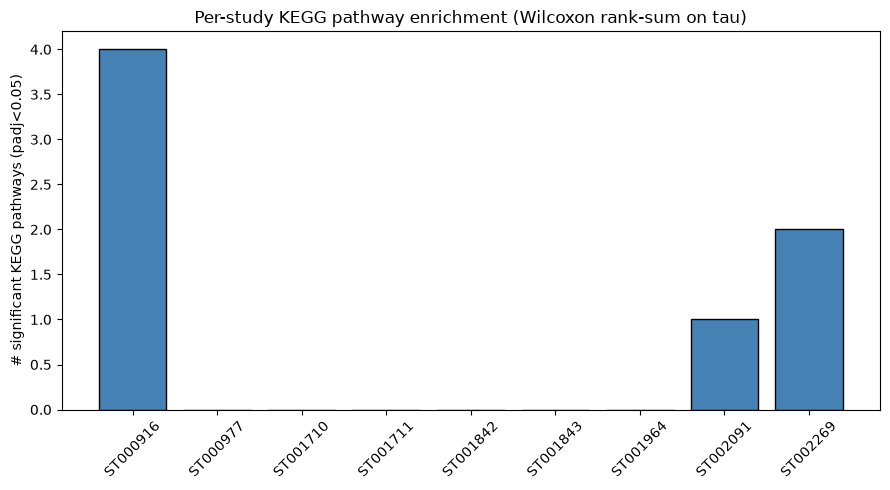

In [66]:
fig, ax = plt.subplots(figsize=(9, 5))
n_sig_per_study = enrichment_summary.groupby("study_id").size().reindex(
    [f.split("/")[-1].split("_", 1)[0] for f in study_files], fill_value=0
)
ax.bar(n_sig_per_study.index, n_sig_per_study.values, color="steelblue", edgecolor="black")
ax.set_ylabel("# significant KEGG pathways (padj<0.05)")
ax.set_title("Per-study KEGG pathway enrichment (Wilcoxon rank-sum on tau)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


# Experiment 2: KEGG enrichment on random-walk-Laplacian-smoothed tau

Smooth each study's raw tau over its own induced subgraph of the core
network's *direct* (single-hop) posonly correlation edges before repeating
the same `kegg_wilcoxon` pathway analysis, to see whether denoising tau
against its correlation neighborhood changes which pathways come out
significant.

Smoothing operator: the random-walk graph Laplacian `L = I - D^-1 A`, where
`A` is the weighted adjacency restricted to this study's tested metabolites
(edge weight = `r`, positive-edges-only, same convention as `posonly`
elsewhere in this notebook) and `D` is the diagonal degree matrix. One
smoothing step is `(I - L) tau = D^-1 A tau`, i.e. replace each node's tau
with the degree-weighted average of its direct neighbors' tau.

`L` preserves constants (`L @ ones = 0`), so this step removes
between-neighbor variation without shifting the overall level of tau -- a
constant tau vector is a fixed point, only deviations from local neighborhood
means get pulled in. The symmetric (`I - D^-1/2 A D^-1/2`) and unnormalized
(`D - A`) Laplacians don't have that property here: on a weighted correlation
graph with a skewed degree distribution they reweight high- and low-degree
nodes unevenly, biasing the smoothed level itself rather than just denoising
it. Nodes with no within-study neighbor (all of a node's direct edges point
to metabolites not tested in this study) are left at their raw tau -- there's
nothing to average against.

In [67]:
edges = pd.read_parquet(CORE_GRAPH_DIR / "edges.parquet")
edges_pos = edges.loc[edges["r"] > 0, ["source", "target", "weight"]]
print("posonly direct edges (whole core graph):", len(edges_pos))


posonly direct edges (whole core graph): 793065


In [73]:
from scipy import sparse


def rw_laplacian_smooth(tau, edges_pos, lam=1.0, transform=None):
    """`lam` step of random-walk-Laplacian diffusion: (I - lam*L) @ tau
    = (1-lam)*tau + lam*(D^-1 A)@tau, on the subgraph induced by tau's own
    index. lam=1 is a full step (each node replaced by its neighbor
    average); lam=0 is a no-op. Nodes with degree 0 keep their raw tau
    unchanged regardless of lam."""
    nodes = tau.index
    idx = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)

    e = edges_pos[edges_pos["source"].isin(idx) & edges_pos["target"].isin(idx)]
    rows = e["source"].map(idx).to_numpy()
    cols = e["target"].map(idx).to_numpy()
    w = e["weight"].to_numpy()

    A = sparse.coo_matrix((w, (rows, cols)), shape=(n, n))
    if transform is not None:
        A.data = transform(A.data)
    A = (A + A.T).tocsr()  # edges stored once per unordered pair -- symmetrize

    x = tau.loc[nodes].to_numpy(dtype=float)
    degree = np.asarray(A.sum(axis=1)).ravel()
    has_neighbors = degree > 0

    x_smooth = x.copy()
    neighbor_avg = (A[has_neighbors] @ x) / degree[has_neighbors]
    x_smooth[has_neighbors] = (1 - lam) * x[has_neighbors] + lam * neighbor_avg

    return pd.Series(x_smooth, index=nodes), has_neighbors.sum(), n


## Choosing a smoothing strength (lambda)

`lam=1` above is a *full* step: every node with a within-study neighbor gets
entirely replaced by its neighbor average, which is too aggressive -- it
overwrites each metabolite's own measured tau completely rather than just
denoising it, which is why the raw-vs-smoothed comparison above mostly lost
matches instead of gaining them. Treat `lam` as a step size on the diffusion
`(I - lam*L)` and sweep it to find a gentler blend between "keep the raw
value" (`lam=0`) and "replace with the neighbor average" (`lam=1`).

In [87]:
lam_grid = np.linspace(0.0, 2.0, 21) # 0.0, 0.1, 0.2, ..., 2.0
n_sig_by_lam = []

for lam in lam_grid:
    total_sig = 0
    for f in study_files:
        study_id = f.split("/")[-1].split("_", 1)[0]
        df = pd.read_csv(f).dropna(subset=["kendall_tau"])
        tau = df.groupby("refmet_id")["kendall_tau"].mean()

        tau_smooth, _, _ = rw_laplacian_smooth(tau, edges_pos, lam=lam, transform=lambda w: w**2)

        kegg_ids = refmet_to_kegg.reindex(tau_smooth.index)
        quant = pd.Series(tau_smooth.values, index=kegg_ids.values).dropna()
        quant = quant.groupby(level=0).mean()

        try:
            results = kegg_wilcoxon(quant, pathways=pathways, min_pathway_size=2)
        except ValueError:
            continue
        total_sig += (results["padj"] < 0.05).sum()

    n_sig_by_lam.append(total_sig)
    print(f"lam={lam:.1f}  total significant pathway hits (summed over studies)={total_sig}")

n_sig_by_lam = np.array(n_sig_by_lam)


lam=0.0  total significant pathway hits (summed over studies)=7
lam=0.1  total significant pathway hits (summed over studies)=8
lam=0.2  total significant pathway hits (summed over studies)=9
lam=0.3  total significant pathway hits (summed over studies)=9
lam=0.4  total significant pathway hits (summed over studies)=9
lam=0.5  total significant pathway hits (summed over studies)=9
lam=0.6  total significant pathway hits (summed over studies)=10
lam=0.7  total significant pathway hits (summed over studies)=10
lam=0.8  total significant pathway hits (summed over studies)=7
lam=0.9  total significant pathway hits (summed over studies)=6
lam=1.0  total significant pathway hits (summed over studies)=10
lam=1.1  total significant pathway hits (summed over studies)=4
lam=1.2  total significant pathway hits (summed over studies)=3
lam=1.3  total significant pathway hits (summed over studies)=1
lam=1.4  total significant pathway hits (summed over studies)=1
lam=1.5  total significant pathway hi

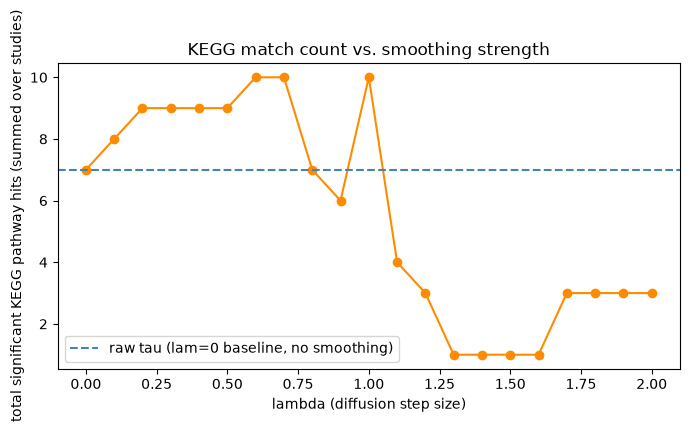

chosen lambda (argmax): 0.6000000000000001


In [110]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lam_grid, n_sig_by_lam, marker="o", color="darkorange")
ax.axhline((enrichment_summary["study_id"].value_counts().sum() if not enrichment_summary.empty else 0),
           color="steelblue", ls="--", label="raw tau (lam=0 baseline, no smoothing)")
ax.set_xlabel("lambda (diffusion step size)")
ax.set_ylabel("total significant KEGG pathway hits (summed over studies)")
ax.set_title("KEGG match count vs. smoothing strength")
ax.legend()
fig.tight_layout()
plt.show()

LAM = lam_grid[n_sig_by_lam==max(n_sig_by_lam)][0] # min lambda that achieves the maximum number of significant hits
print("chosen lambda (argmax):", LAM)


ST000916: lam=0.6  256/357 nodes smoothed against >=1 within-study neighbor -- 75/357 mapped to a KEGG ID, 25 pathway(s) tested, 6 significant (padj<0.05)


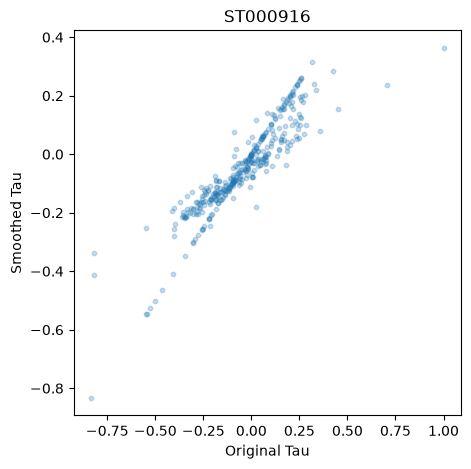

ST000977: lam=0.6  61/70 nodes smoothed against >=1 within-study neighbor -- 35/70 mapped to a KEGG ID, 12 pathway(s) tested, 0 significant (padj<0.05)


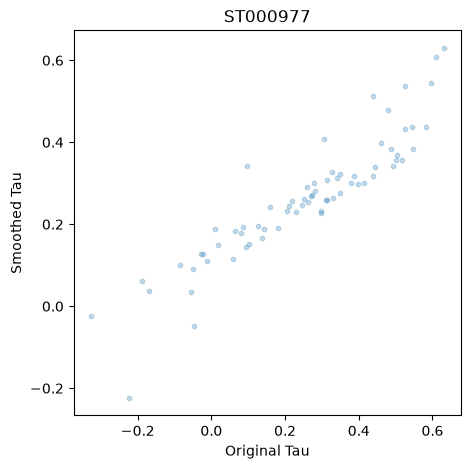

ST001710: lam=0.6  135/149 nodes smoothed against >=1 within-study neighbor -- 7/149 mapped to a KEGG ID, 4 pathway(s) tested, 0 significant (padj<0.05)


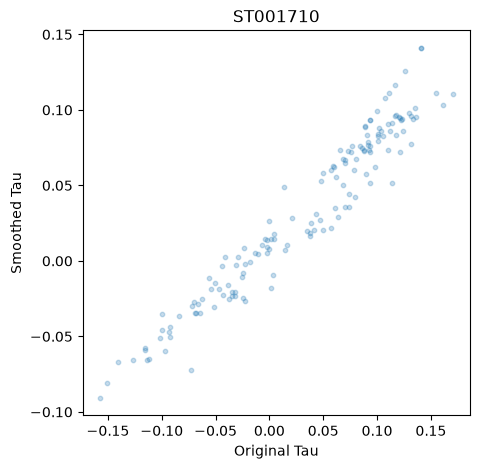

ST001711: lam=0.6  31/31 nodes smoothed against >=1 within-study neighbor -- 30/31 mapped to a KEGG ID, 52 pathway(s) tested, 0 significant (padj<0.05)


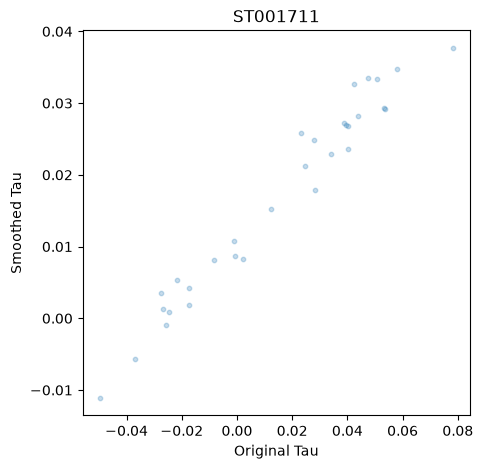

ST001842: lam=0.6  140/148 nodes smoothed against >=1 within-study neighbor -- 135/148 mapped to a KEGG ID, 86 pathway(s) tested, 1 significant (padj<0.05)


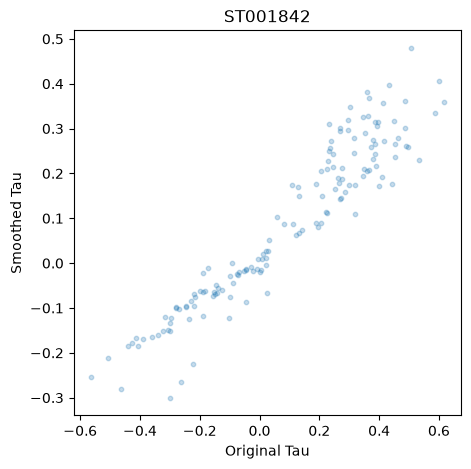

ST001843: lam=0.6  268/277 nodes smoothed against >=1 within-study neighbor -- 20/277 mapped to a KEGG ID, 9 pathway(s) tested, 0 significant (padj<0.05)


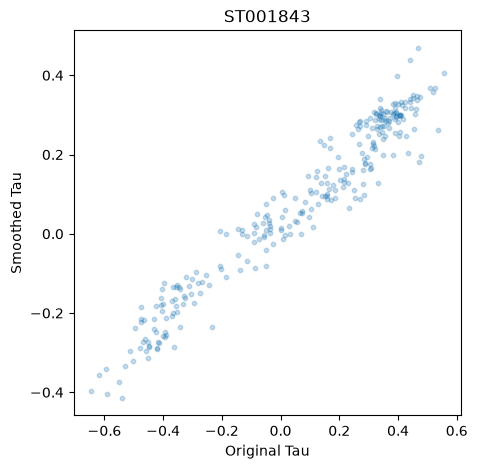

ST001964: lam=0.6  15/19 nodes smoothed against >=1 within-study neighbor -- 5/19 mapped to a KEGG ID, 1 pathway(s) tested, 0 significant (padj<0.05)


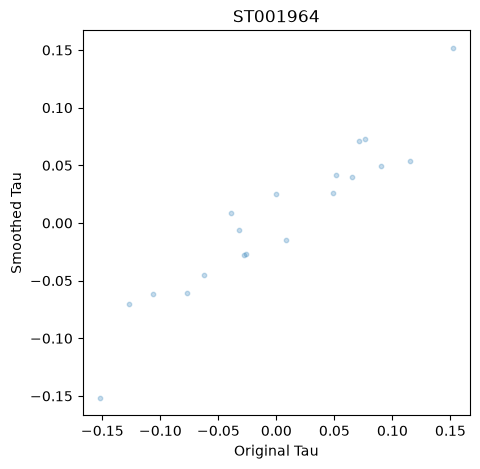

ST002091: lam=0.6  679/699 nodes smoothed against >=1 within-study neighbor -- 15/699 mapped to a KEGG ID, 9 pathway(s) tested, 1 significant (padj<0.05)


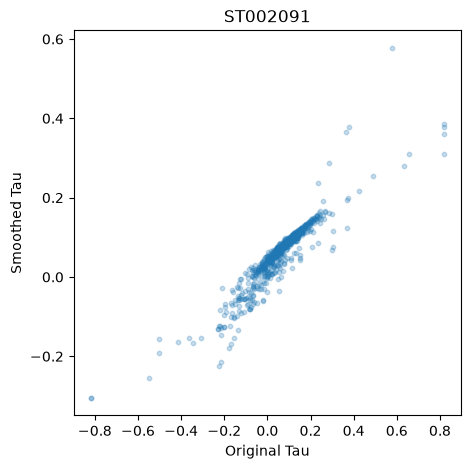

ST002269: lam=0.6  309/342 nodes smoothed against >=1 within-study neighbor -- 43/342 mapped to a KEGG ID, 43 pathway(s) tested, 2 significant (padj<0.05)


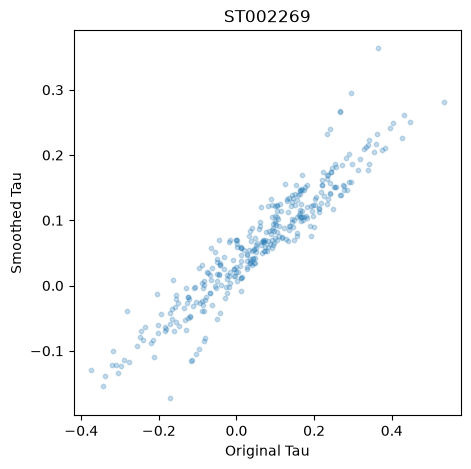

,n_total,n_with_neighbors,n_isolated
study_id,,,
ST000916,357,256,101
ST000977,70,61,9
ST001710,149,135,14
ST001711,31,31,0
ST001842,148,140,8
ST001843,277,268,9
ST001964,19,15,4
ST002091,699,679,20
ST002269,342,309,33


In [111]:
enrichment_by_study_smoothed = {}
enrichment_summary_smoothed = []
smoothing_stats = []

for f in study_files:
    study_id = f.split("/")[-1].split("_", 1)[0]

    df = pd.read_csv(f).dropna(subset=["kendall_tau"])
    tau = df.groupby("refmet_id")["kendall_tau"].mean()

    tau_smooth, n_with_neighbors, n_total = rw_laplacian_smooth(tau, edges_pos, lam=LAM, transform=lambda w: w**2)
    smoothing_stats.append({
        "study_id": study_id, "n_total": n_total,
        "n_with_neighbors": n_with_neighbors, "n_isolated": n_total - n_with_neighbors,
    })

    kegg_ids = refmet_to_kegg.reindex(tau_smooth.index)
    quant = pd.Series(tau_smooth.values, index=kegg_ids.values).dropna()
    quant = quant.groupby(level=0).mean()

    n_mapped = len(quant)

    try:
        results = kegg_wilcoxon(quant, pathways=pathways, min_pathway_size=2)
    except ValueError:
        print(f"{study_id}: {n_with_neighbors}/{n_total} nodes had >=1 within-study "
              f"neighbor to smooth against -- {n_mapped}/{n_total} mapped to a KEGG ID, "
              f"no pathway had >=2 mapped members -- skipped")
        continue

    sig = results.query("padj < 0.05").copy()
    sig.insert(0, "study_id", study_id)

    enrichment_by_study_smoothed[study_id] = results
    enrichment_summary_smoothed.append(sig)

    print(f"{study_id}: lam={LAM:.1f}  {n_with_neighbors}/{n_total} nodes smoothed against >=1 "
          f"within-study neighbor -- {n_mapped}/{n_total} mapped to a KEGG ID, "
          f"{len(results)} pathway(s) tested, {len(sig)} significant (padj<0.05)")
    
    
    plt.figure(figsize=(5, 5))
    plt.title(f"{study_id}")
    plt.scatter(
        tau, tau_smooth, alpha=.25, s=10
    )
    plt.xlabel("Original Tau")
    plt.ylabel("Smoothed Tau")
    plt.show()

enrichment_summary_smoothed = (
    pd.concat(enrichment_summary_smoothed, ignore_index=True)
    if enrichment_summary_smoothed else pd.DataFrame()
)
smoothing_stats = pd.DataFrame(smoothing_stats).set_index("study_id")
smoothing_stats

In [112]:
enrichment_summary_smoothed

,study_id,pathway_id,pathway_name,n_pathway,n_background,statistic,pval,median_in,median_out,mean_in,mean_out,padj
0,ST000916,hsa00590,Arachidonic acid metabolism - Homo sapiens (hu...,15,75,692.0,0.001380,0.137407,-0.014784,0.118301,-0.009355,0.015365
1,ST000916,hsa04979,Cholesterol metabolism - Homo sapiens (human),4,75,22.0,0.001601,-0.154083,0.026229,-0.194570,0.028049,0.015365
2,ST000916,hsa04977,Vitamin digestion and absorption - Homo sapien...,3,75,11.0,0.002458,-0.163333,0.024198,-0.217458,0.025911,0.015365
3,ST000916,hsa04975,Fat digestion and absorption - Homo sapiens (h...,3,75,11.0,0.002458,-0.163333,0.024198,-0.217458,0.025911,0.015365
4,ST000916,hsa04976,Bile secretion - Homo sapiens (human),2,75,4.0,0.006486,-0.253771,0.022167,-0.253771,0.023572,0.032432
5,ST000916,hsa04071,Sphingolipid signaling pathway - Homo sapiens ...,6,75,80.0,0.010726,-0.122314,0.026835,-0.109644,0.027117,0.044692
6,ST001842,hsa00280,"Valine, leucine and isoleucine degradation - H...",4,135,29.0,0.000367,-0.163074,0.090192,-0.165723,0.092470,0.031546
7,ST002091,hsa01040,Biosynthesis of unsaturated fatty acids - Homo...,5,15,47.0,0.004662,0.043731,-0.000289,0.051704,-0.020496,0.041958
8,ST002269,hsa01210,2-Oxocarboxylic acid metabolism - Homo sapiens...,11,43,313.0,0.000145,0.154521,0.059052,0.167438,0.054365,0.006235
9,ST002269,hsa00230,Purine metabolism - Homo sapiens (human),2,43,0.0,0.002215,-0.096916,0.087125,-0.096916,0.092081,0.047619


## Raw vs. smoothed tau: significant KEGG pathways per study

In [113]:
study_ids = [f.split("/")[-1].split("_", 1)[0] for f in study_files]

n_sig_raw = enrichment_summary.groupby("study_id").size().reindex(study_ids, fill_value=0)
n_sig_smoothed = enrichment_summary_smoothed.groupby("study_id").size().reindex(study_ids, fill_value=0) \
    if not enrichment_summary_smoothed.empty else pd.Series(0, index=study_ids)

comparison = pd.DataFrame({
    "n_sig_raw": n_sig_raw, "n_sig_smoothed": n_sig_smoothed,
    "n_isolated": smoothing_stats["n_isolated"].reindex(study_ids),
    "n_total": smoothing_stats["n_total"].reindex(study_ids),
})
comparison["delta"] = comparison["n_sig_smoothed"] - comparison["n_sig_raw"]
comparison


,n_sig_raw,n_sig_smoothed,n_isolated,n_total,delta
study_id,,,,,
ST000916,4,6,101,357,2
ST000977,0,0,9,70,0
ST001710,0,0,14,149,0
ST001711,0,0,0,31,0
ST001842,0,1,8,148,1
ST001843,0,0,9,277,0
ST001964,0,0,4,19,0
ST002091,1,1,20,699,0
ST002269,2,2,33,342,0


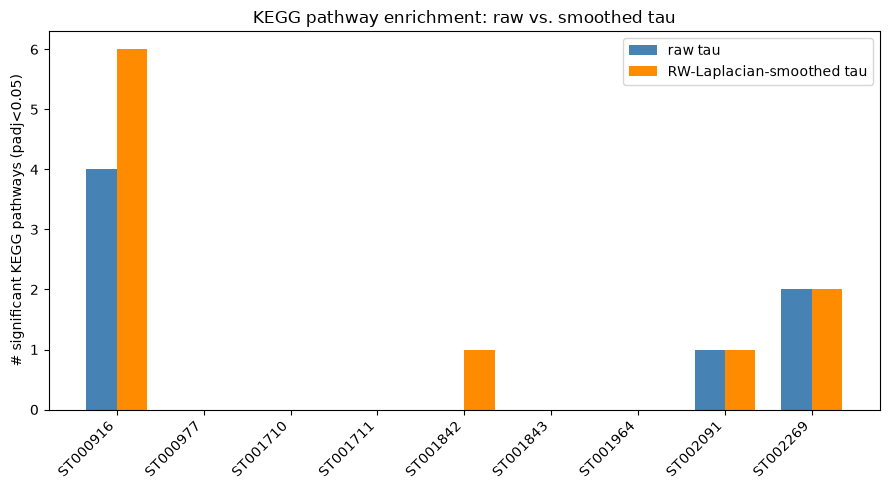

In [114]:
fig, ax = plt.subplots(figsize=(9, 5))
width = 0.35
xpos = np.arange(len(study_ids))
ax.bar(xpos - width / 2, comparison["n_sig_raw"], width, color="steelblue", label="raw tau")
ax.bar(xpos + width / 2, comparison["n_sig_smoothed"], width, color="darkorange", label="RW-Laplacian-smoothed tau")
ax.set_xticks(xpos)
ax.set_xticklabels(study_ids, rotation=45, ha="right")
ax.set_ylabel("# significant KEGG pathways (padj<0.05)")
ax.set_title("KEGG pathway enrichment: raw vs. smoothed tau")
ax.legend()
fig.tight_layout()
plt.show()


In [115]:
pathways_gained = {}
pathways_lost = {}

for sid in study_ids:
    raw_hits = set(enrichment_summary.loc[enrichment_summary["study_id"] == sid, "pathway_id"]) \
        if not enrichment_summary.empty else set()
    smooth_hits = set(enrichment_summary_smoothed.loc[enrichment_summary_smoothed["study_id"] == sid, "pathway_id"]) \
        if not enrichment_summary_smoothed.empty else set()

    gained = smooth_hits - raw_hits
    lost = raw_hits - smooth_hits
    if gained:
        pathways_gained[sid] = gained
    if lost:
        pathways_lost[sid] = lost

    if gained or lost:
        print(f"{sid}: gained={sorted(gained)}  lost={sorted(lost)}")

if not pathways_gained and not pathways_lost:
    print("no change in significant pathway sets after smoothing, for any study")


ST000916: gained=['hsa00590', 'hsa04071']  lost=[]
ST001842: gained=['hsa00280']  lost=[]
